# Triangle plots for subluminal chains, constant $c_s^2$

In [1]:
import numpy as np
import getdist
from getdist import plots

import utils

In [2]:
indices = list(range(56, 60)) + [48, 83] # TODO: run chain 47
chains = {}
for i in indices:
    chains[i] = utils.load_chain(i, burn_in=0.2, smooth_2D=0.3)

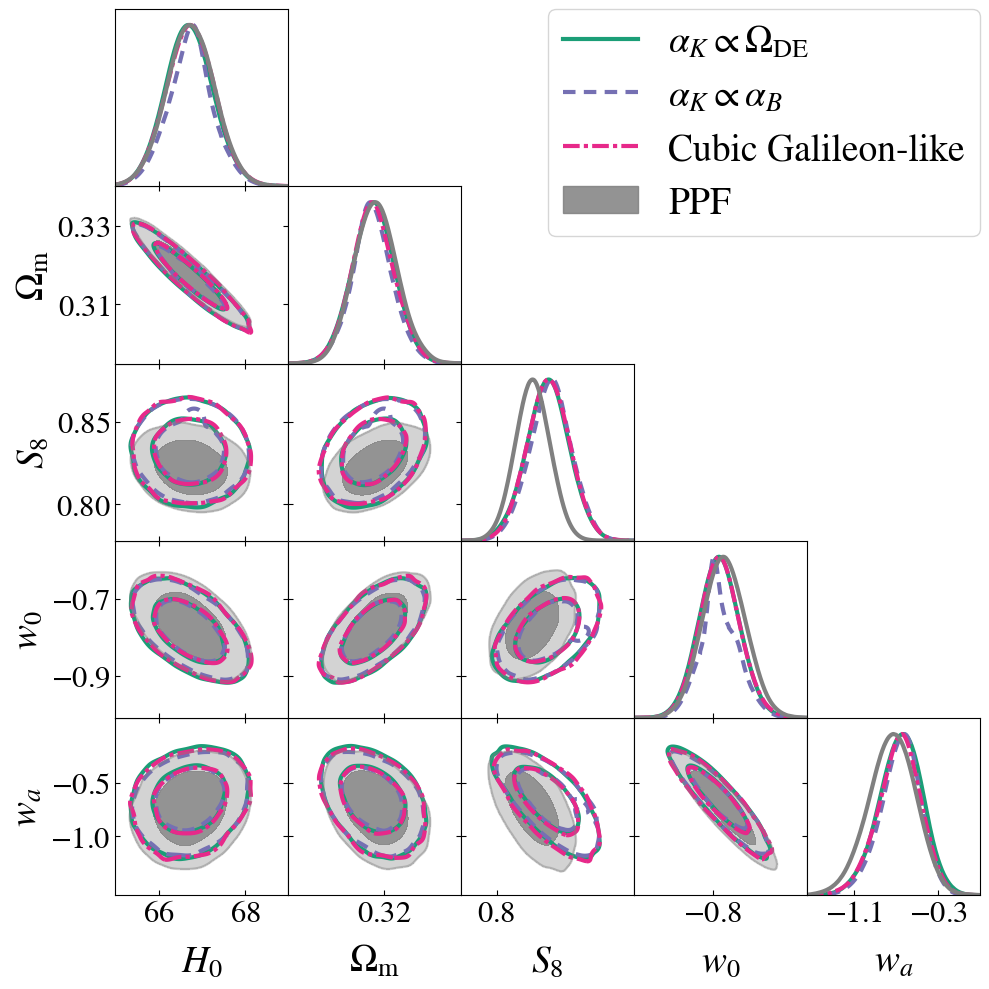

In [3]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[56], chains[58], chains[59], chains[48]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[False, False, False, True],
    contour_colors=[utils.colors[0], utils.colors[2], utils.colors[3], "gray"],
    contour_lws=3,
    contour_ls=["-", "--", "-.", "-"],
    legend_labels=["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like", "PPF"],
    legend_loc="upper right",
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)
p.fig.savefig("plots/triangle_ds1_subluminal_mg.pdf", bbox_inches="tight")

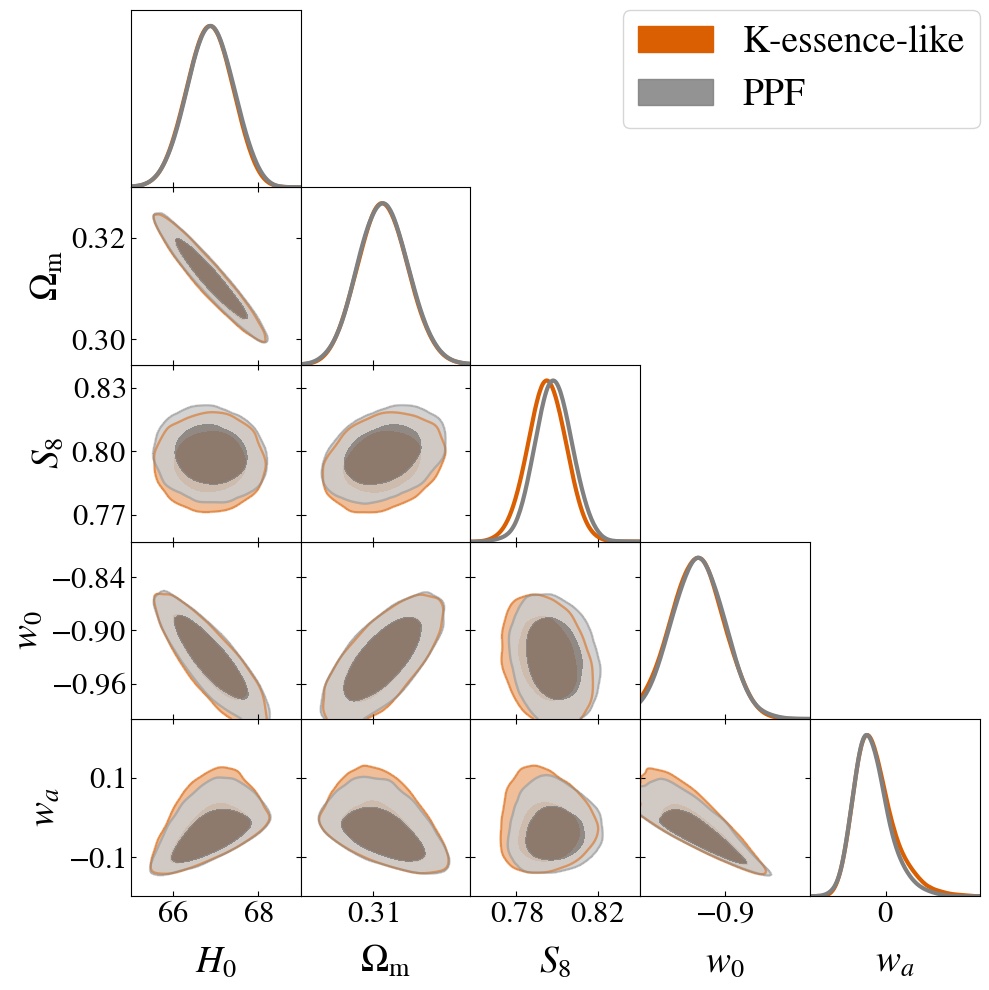

In [4]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[57], chains[83]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[True, True],
    contour_colors=[utils.colors[1], "gray"],
    contour_lws=3,
    contour_ls='-',
    legend_labels=["K-essence-like", "PPF"],
    legend_loc="upper right",
    param_limits={"w": [-1, -0.8], "H0": [65, 69], "omegam": [0.295, 0.33]}
)
# p.fig.text(0.3, 1.01, "Data: Planck + DESI + DES-Dovekie", fontsize=20)
p.fig.savefig("plots/triangle_ds1_subluminal_mg_kessence.pdf", bbox_inches="tight")

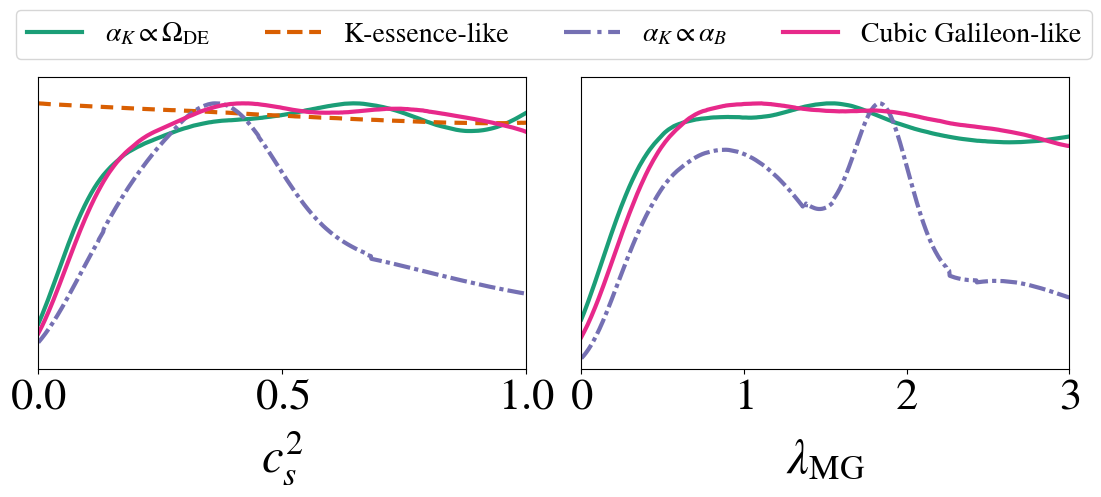

In [5]:
p = plots.get_subplot_plotter(width_inch=11, subplot_size_ratio=4/5)
p.settings.axes_fontsize=32
p.settings.axes_labelsize=35
p.settings.legend_fontsize=30
labels = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence-like", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like"]
p.plots_1d(
    [chains[56], chains[57], chains[58], chains[59]],
    ["cs2_0", "alpha_K_0"],
    colors=utils.colors,
    lws=3,
    ls=["-", "--", "-.", "-"],
    nx=2,
    legend_labels=[],
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)

from matplotlib.lines import Line2D

handles = [
    Line2D([], [], linewidth=3, linestyle="-",  color=utils.colors[0]),
    Line2D([], [], linewidth=3, linestyle="--", color=utils.colors[1]),
    Line2D([], [], linewidth=3, linestyle="-.", color=utils.colors[2]),
    Line2D([], [], linewidth=3, linestyle="-",  color=utils.colors[3]),
]

# place legend relative to the figure (x,y in figure coordinates)
p.fig.legend(handles, labels,
             loc="upper center",
             ncol=4,
             fontsize=20,
             bbox_to_anchor=(0.508, 1.15),
             bbox_transform=p.fig.transFigure,
             frameon=True)

p.fig.savefig("plots/lambda_mg_cs2_subluminal_ds1.pdf", bbox_inches="tight")

In [11]:
# Getting numbers
for i, chain in chains.items():
    try: print(f"{i}: {chain.getInlineLatex('H0')}, {chain.getInlineLatex('ns')}, {chain.getInlineLatex('omegam')}, {chain.getInlineLatex('S8')}, {chain.getInlineLatex('w')}, {chain.getInlineLatex('wa')}, {chain.getInlineLatex('cs2_0', limit=2)}")
    except Exception: print(f"{i}: {chain.getInlineLatex('H0')}, {chain.getInlineLatex('ns')}, {chain.getInlineLatex('omegam')}, {chain.getInlineLatex('S8')}, {chain.getInlineLatex('w')}, {chain.getInlineLatex('wa')}")

56: H_0 = 66.71\pm 0.56, n_\mathrm{s} = 0.9695\pm 0.0036, \Omega_\mathrm{m} = 0.3171\pm 0.0056, S_8 = 0.832\pm 0.013, w_0 = -0.784\pm 0.055, w_a = -0.66^{+0.22}_{-0.19}, c_s^2 = ---
57: H_0 = 66.86\pm 0.54, n_\mathrm{s} = 0.9739\pm 0.0034, \Omega_\mathrm{m} = 0.3120\pm 0.0052, S_8 = 0.7950\pm 0.0097, w_0 = -0.932\pm 0.030, w_a = -0.028^{+0.036}_{-0.063}, c_s^2 = ---
58: H_0 = 66.74\pm 0.53, n_\mathrm{s} = 0.9697^{+0.0035}_{-0.0032}, \Omega_\mathrm{m} = 0.3169\pm 0.0053, S_8 = 0.833\pm 0.013, w_0 = -0.783\pm 0.051, w_a = -0.66^{+0.20}_{-0.17}, c_s^2 = 0.45^{+0.50}_{-0.38}
59: H_0 = 66.74\pm 0.56, n_\mathrm{s} = 0.9691\pm 0.0035, \Omega_\mathrm{m} = 0.3171\pm 0.0056, S_8 = 0.832\pm 0.013, w_0 = -0.782\pm 0.055, w_a = -0.67^{+0.22}_{-0.19}, c_s^2 > 0.113
48: H_0 = 66.74\pm 0.59, n_\mathrm{s} = 0.9686\pm 0.0036, \Omega_\mathrm{m} = 0.3177\pm 0.0060, S_8 = 0.822\pm 0.011, w_0 = -0.771\pm 0.061, w_a = -0.74^{+0.24}_{-0.22}
83: H_0 = 66.87\pm 0.59, n_\mathrm{s} = 0.9737\pm 0.0034, \Omega_\mat